# Crop Recommendation System: Distance Metrics and K-Means++ Search Optimization

**Author:** Dang Tran  
**Problem type:** Top-$K$ recommendation / ranking  

## Meeting-aligned objective

Given soil and weather features, return a ranked list of the **Top-$K$ most suitable crops**.

- **Input features:** Nitrogen, phosphorus, potassium, temperature, humidity, pH, and rainfall.
- **Output:** ranked list of Top-$K$ crop labels.
- **Models compared:**
  1. **KNN baseline:** searches the entire training set.
  2. **KNN + K-Means++ search optimizer:** searches only samples in the nearest clusters, whose centroids act as search representatives.
- **Distance functions:** Euclidean, Manhattan, and Cosine distance.
- **Evaluation:** Precision@$K$, Recall@$K$, MAP@$K$, Hit Rate@$K$, and NDCG@$K$, plus inference latency and candidate-set reduction.

> **Important evaluation note:** This dataset provides one ground-truth crop label per row. Therefore, Recall@$K$ and Hit Rate@$K$ are numerically identical. They are both reported because they are commonly requested recommendation metrics, but their interpretation is discussed explicitly below.

## 1. Environment and reproducibility



In [24]:
from pathlib import Path
from time import perf_counter
import warnings
# from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TOP_K = 5
DISTANCE_METRICS = ["euclidean", "manhattan", "cosine"]

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## 2. Load and clean the dataset

All-empty columns are removed automatically. The code also standardizes feature names to lowercase so later cells are independent of capitalization in the source file.

In [25]:
# drive.mount('/content/mydrive')
DATA_CANDIDATES = [
    Path("/mnt/data/Crop_recommendation.csv"),
    Path("/content/Crop_recommendation.csv"),
    Path("/content/mydrive/MyDrive/AIO2026/Dataset/Crop_recommendation.csv"),
    Path("../data/raw/Crop_recommendation.csv"),
    Path("Crop_recommendation.csv"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Crop_recommendation.csv was not found. Upload it beside this notebook "
        "or update DATA_CANDIDATES with the correct path."
    )

raw_df = pd.read_csv(DATA_PATH)
raw_df.columns = [str(c).strip().lower() for c in raw_df.columns]

all_empty_columns = raw_df.columns[raw_df.isna().all()].tolist()
df = raw_df.drop(columns=all_empty_columns).copy()

TARGET_COLUMN = "label"
if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Expected target column '{TARGET_COLUMN}', found: {df.columns.tolist()}")

FEATURE_COLUMNS = [c for c in df.columns if c != TARGET_COLUMN]

print(f"Loaded: {DATA_PATH}")
print(f"Original shape: {raw_df.shape}")
print(f"Removed all-empty columns: {all_empty_columns}")
print(f"Clean shape: {df.shape}")
print(f"Features ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}")
print(f"Crop classes: {df[TARGET_COLUMN].nunique()}")
display(df.head())

Loaded: ..\data\raw\Crop_recommendation.csv
Original shape: (2200, 10)
Removed all-empty columns: ['unnamed: 8', 'unnamed: 9']
Clean shape: (2200, 8)
Features (7): ['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph', 'rainfall']
Crop classes: 22


,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Dataset analysis

This section examines data types, missing values, class balance, numerical ranges, distributions, outliers, correlations, and class-level feature profiles.

In [26]:
summary_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
})

display(summary_table)
display(df[FEATURE_COLUMNS].describe().T.round(3))

,dtype,missing,missing_pct,unique_values
nitrogen,int64,0,0.0,137
phosphorus,int64,0,0.0,117
potassium,int64,0,0.0,73
temperature,float64,0,0.0,2200
humidity,float64,0,0.0,2200
ph,float64,0,0.0,2200
rainfall,float64,0,0.0,2200
label,str,0,0.0,22


,count,mean,std,min,25%,50%,75%,max
nitrogen,2200.0,50.552,36.917,0.000,21.000,37.000,84.250,140.000
phosphorus,2200.0,53.363,32.986,5.000,28.000,51.000,68.000,145.000
potassium,2200.0,48.149,50.648,5.000,20.000,32.000,49.000,205.000
temperature,2200.0,25.616,5.064,8.826,22.769,25.599,28.562,43.675
humidity,2200.0,71.482,22.264,14.258,60.262,80.473,89.949,99.982
ph,2200.0,6.469,0.774,3.505,5.972,6.425,6.924,9.935
rainfall,2200.0,103.464,54.958,20.211,64.552,94.868,124.268,298.560


Class counts:


,samples
label,
apple,100
banana,100
blackgram,100
chickpea,100
coconut,100
coffee,100
cotton,100
grapes,100
jute,100


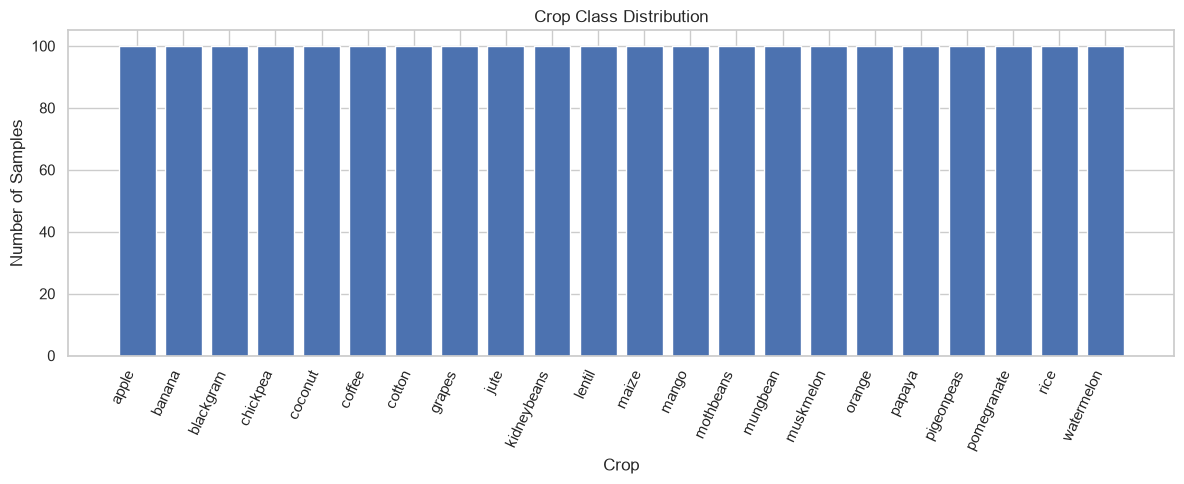

In [27]:
class_counts = df[TARGET_COLUMN].value_counts().sort_index()
print("Class counts:")
display(class_counts.to_frame("samples"))

plt.figure(figsize=(12, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Crop Class Distribution")
plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.xticks(rotation=65, ha="right")
plt.tight_layout()
plt.show()

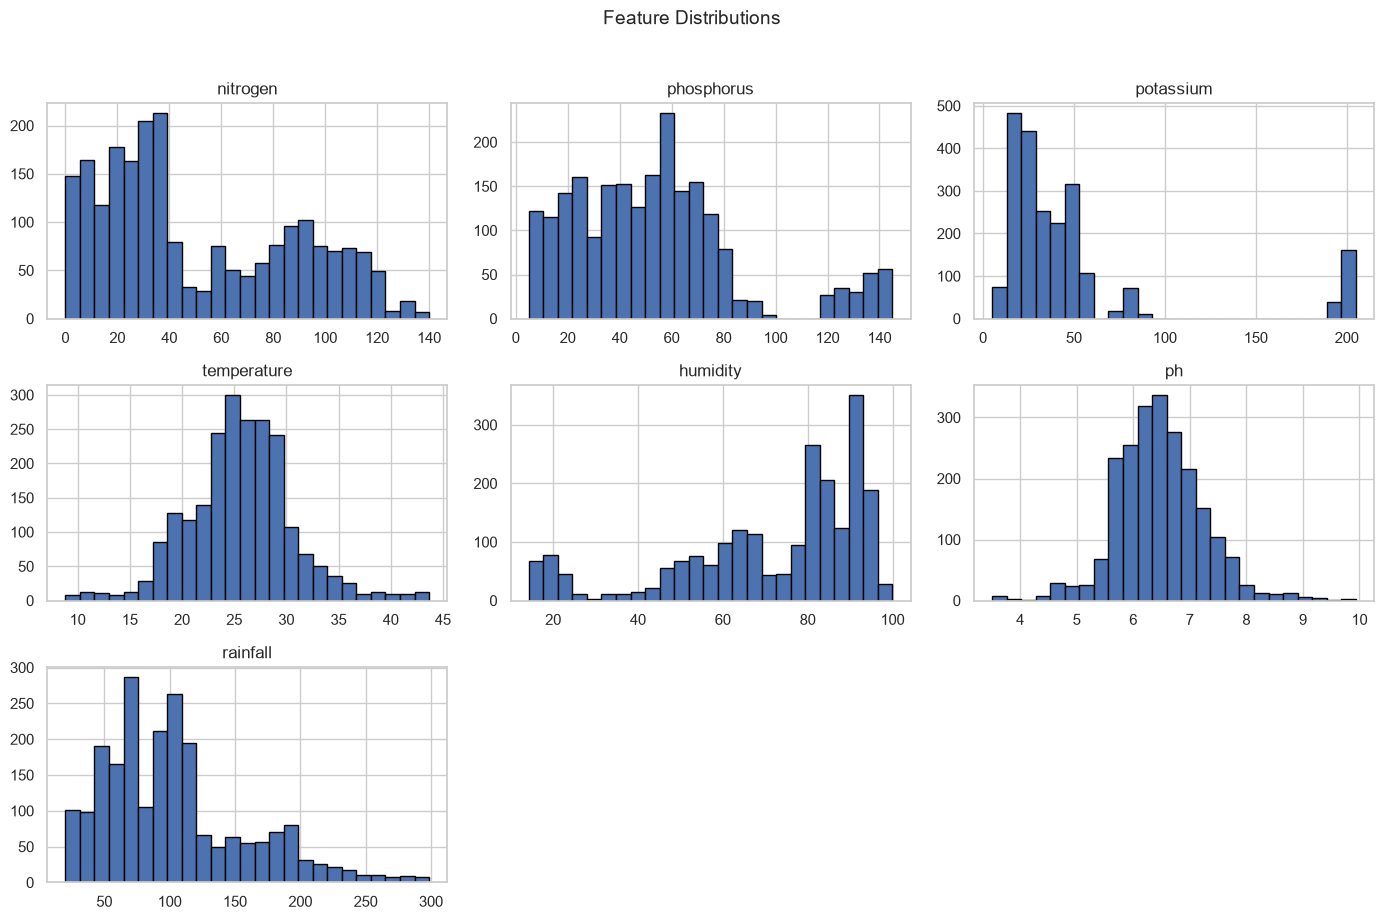

In [28]:
df[FEATURE_COLUMNS].hist(figsize=(14, 9), bins=25, edgecolor="black")
plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

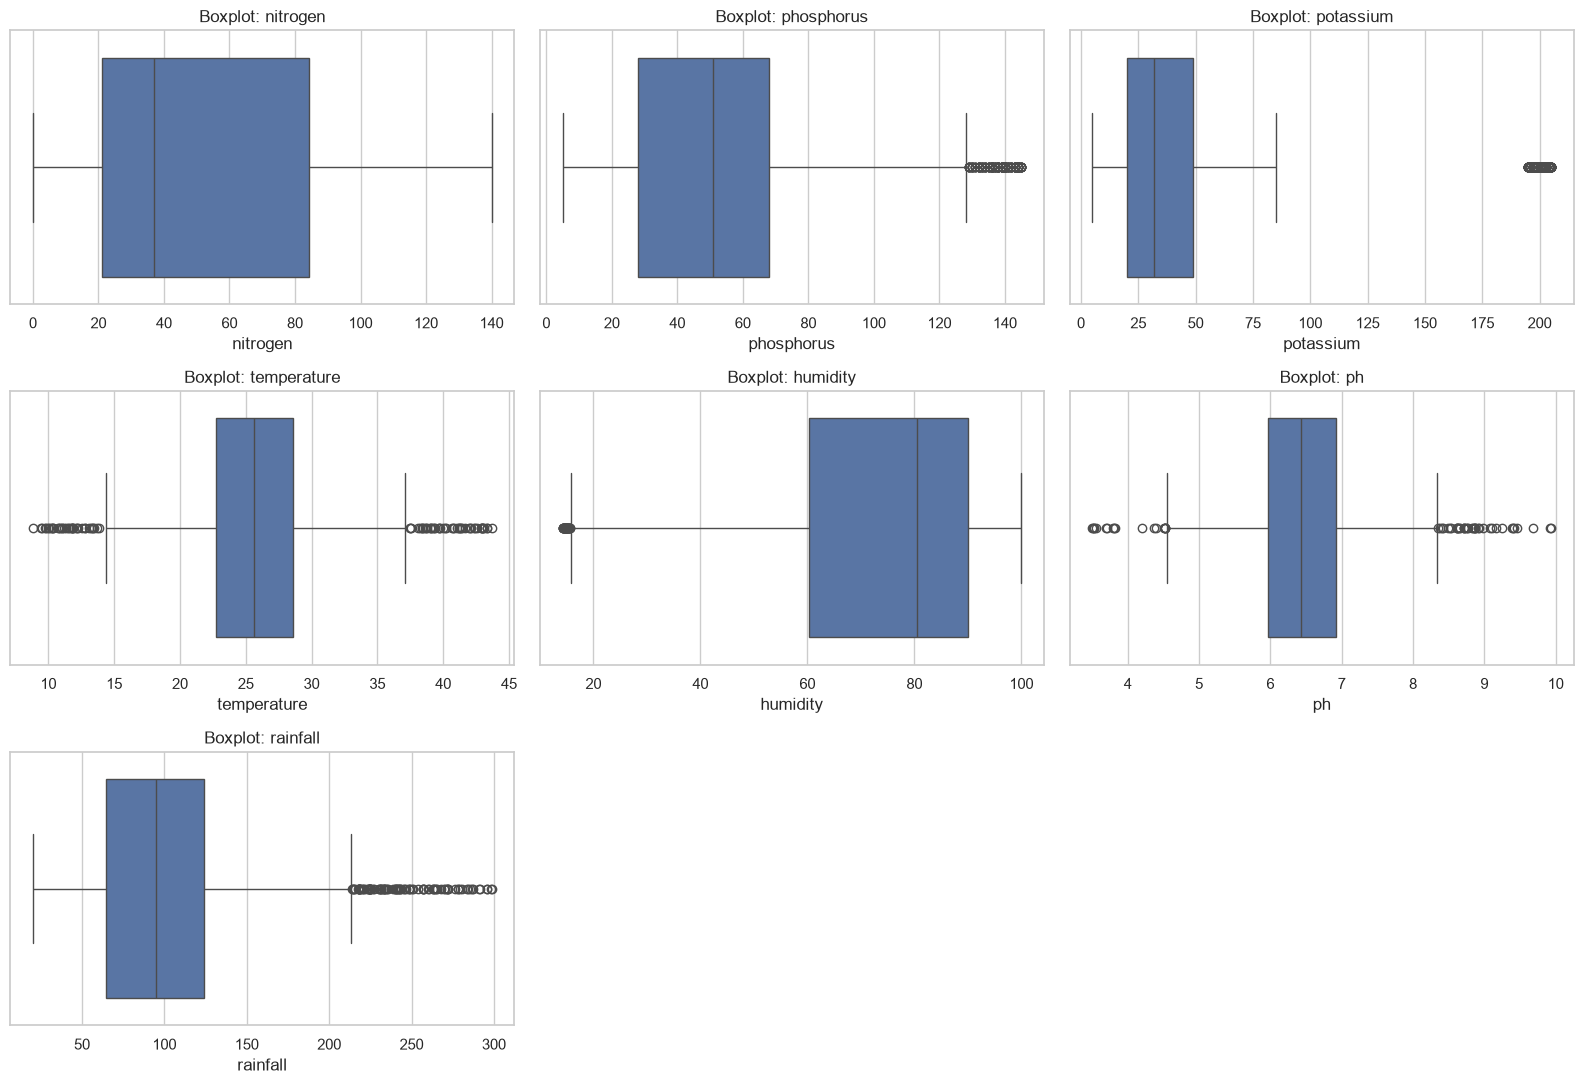

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for ax, feature in zip(axes, FEATURE_COLUMNS):
    sns.boxplot(x=df[feature], ax=ax)
    ax.set_title(f"Boxplot: {feature}")

for ax in axes[len(FEATURE_COLUMNS):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

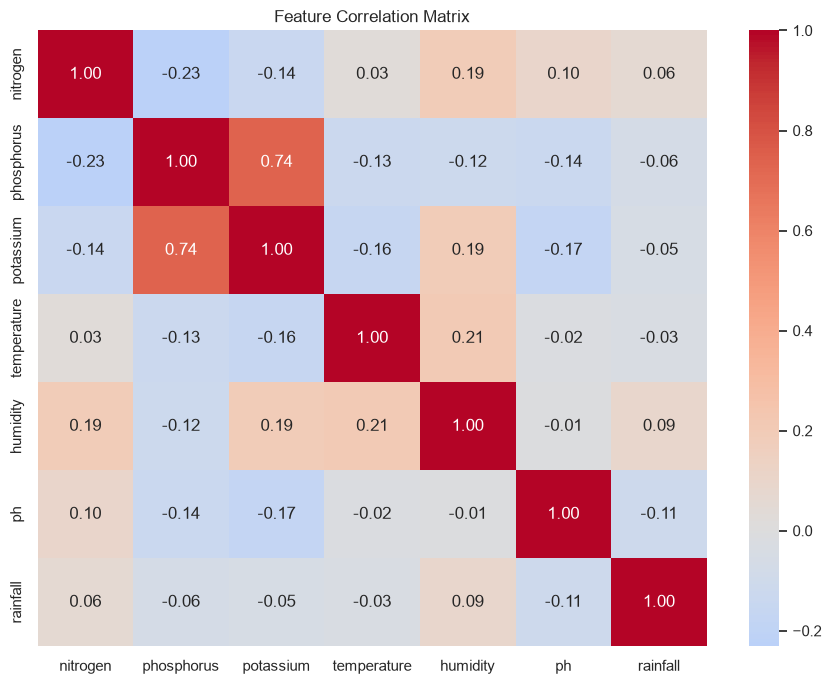

In [30]:
plt.figure(figsize=(9, 7))
corr = df[FEATURE_COLUMNS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

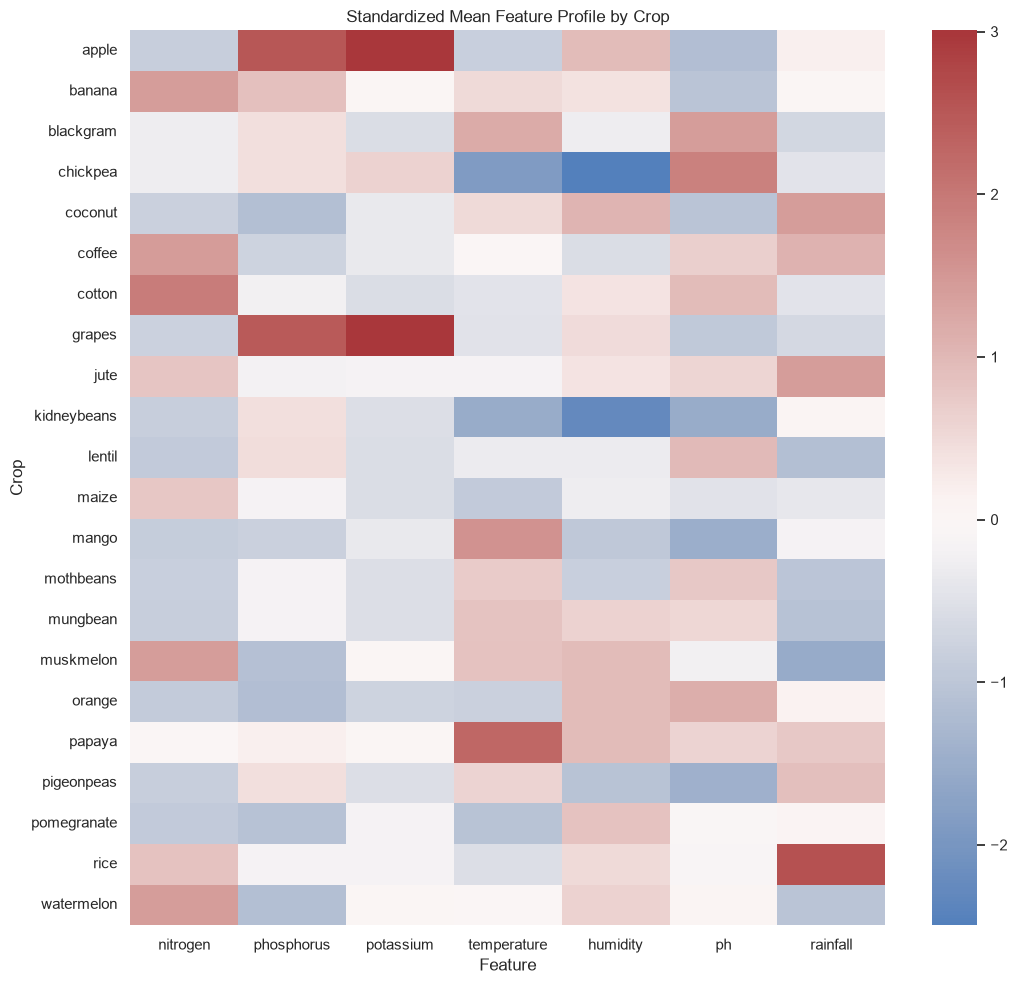

In [31]:
class_profiles = df.groupby(TARGET_COLUMN)[FEATURE_COLUMNS].mean()
profile_z = (class_profiles - class_profiles.mean()) / class_profiles.std(ddof=0)

plt.figure(figsize=(11, 10))
sns.heatmap(profile_z, cmap="vlag", center=0)
plt.title("Standardized Mean Feature Profile by Crop")
plt.xlabel("Feature")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

### EDA interpretation

- Removing the two entirely empty columns prevents meaningless features from entering the model.
- The crop classes are balanced, so stratified splitting gives every crop a similar representation in train, validation, and test sets.
- Feature ranges differ substantially. For example, macronutrients and rainfall use different scales from pH, so distance-based models require scaling.
- Correlated features and class-specific profiles motivate PCA as a diagnostic tool, although the final recommendation models retain all standardized features to preserve information and interpretability.

## 4. Stratified train / validation / test split

The split is performed **before** fitting the imputer, scaler, PCA, KNN model, or K-Means model. This prevents information from validation and test samples from leaking into training.

- Train: 70%
- Validation: 10%
- Test: 20%

In [32]:
X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].astype(str).copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.125,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "samples": [len(X_train), len(X_val), len(X_test)],
    "percentage": [len(X_train)/len(X), len(X_val)/len(X), len(X_test)/len(X)],
    "classes": [y_train.nunique(), y_val.nunique(), y_test.nunique()],
})
split_summary["percentage"] = (split_summary["percentage"] * 100).round(1)
display(split_summary)

class_split_check = pd.concat([
    y_train.value_counts().rename("train"),
    y_val.value_counts().rename("validation"),
    y_test.value_counts().rename("test"),
], axis=1).sort_index()
display(class_split_check)

,split,samples,percentage,classes
0,train,1540,70.0,22
1,validation,220,10.0,22
2,test,440,20.0,22


,train,validation,test
label,,,
apple,70,10,20
banana,70,10,20
blackgram,70,10,20
chickpea,70,10,20
coconut,70,10,20
coffee,70,10,20
cotton,70,10,20
grapes,70,10,20
jute,70,10,20


## 5. Preprocessing: missing values and scaling

1. **Median imputation** is robust to skewed numeric distributions.
2. **Standardization** gives each feature approximately zero mean and unit variance, preventing large-scale features from dominating Euclidean or Manhattan distance.
3. The imputer and scaler are fitted only on the training set during model selection.

In [33]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

scaled_summary = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "train_mean_after_scaling": X_train_scaled.mean(axis=0),
    "train_std_after_scaling": X_train_scaled.std(axis=0),
}).round(4)
display(scaled_summary)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=FEATURE_COLUMNS)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)

X_train_scaled_df.to_csv("../data/processed/train.csv", index=False)
X_val_scaled_df.to_csv("../data/processed/val.csv", index=False)
X_test_scaled_df.to_csv("../data/processed/test.csv", index=False)

,feature,train_mean_after_scaling,train_std_after_scaling
0,nitrogen,0.0,1.0
1,phosphorus,0.0,1.0
2,potassium,0.0,1.0
3,temperature,0.0,1.0
4,humidity,-0.0,1.0
5,ph,0.0,1.0
6,rainfall,0.0,1.0


## 6. PCA analysis

PCA is fitted on the scaled training data only. It is used here to:

- estimate how much variance can be summarized with fewer components;
- visualize whether crop classes form separable regions;
- inspect feature contributions to the principal components.

The recommendation models below use the full standardized feature space by default because only seven input features are available and aggressive dimensionality reduction may remove crop-specific information.

,component,explained_variance_ratio,cumulative_variance
0,1,0.2739,0.2739
1,2,0.1876,0.4615
2,3,0.1513,0.6128
3,4,0.1463,0.7591
4,5,0.1155,0.8746
5,6,0.0979,0.9725
6,7,0.0275,1.0000


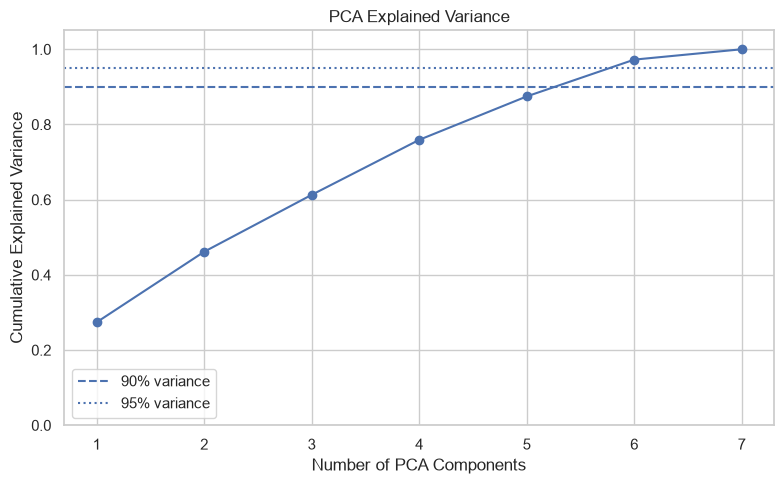

In [34]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

pca_variance = pd.DataFrame({
    "component": np.arange(1, len(FEATURE_COLUMNS) + 1),
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_full.explained_variance_ratio_),
})
display(pca_variance.round(4))

plt.figure(figsize=(8, 5))
plt.plot(pca_variance["component"], pca_variance["cumulative_variance"], marker="o")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle=":", label="95% variance")
plt.xticks(pca_variance["component"])
plt.ylim(0, 1.05)
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

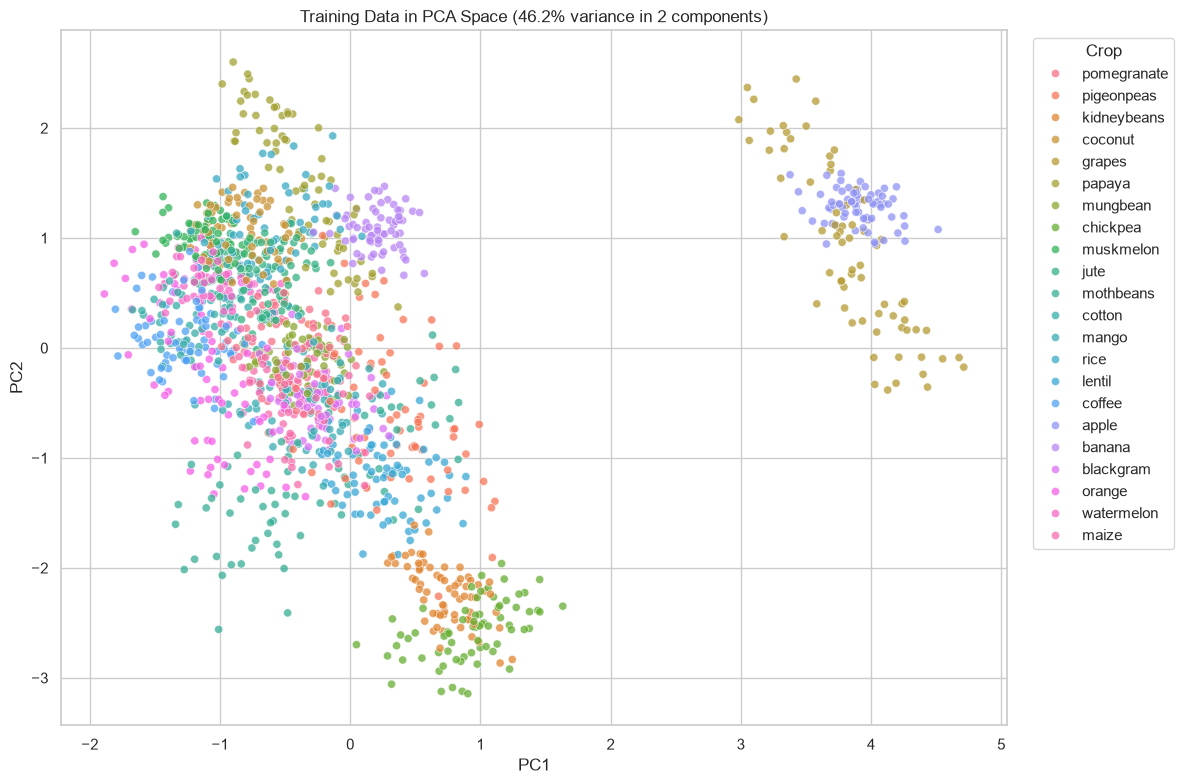

In [35]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": X_train_pca2[:, 0],
    "PC2": X_train_pca2[:, 1],
    "crop": y_train.to_numpy(),
})

plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="crop", s=35, alpha=0.75)
plt.title(
    f"Training Data in PCA Space "
    f"({pca_2d.explained_variance_ratio_.sum():.1%} variance in 2 components)"
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Crop")
plt.tight_layout()
plt.show()

In [36]:
pca_loadings = pd.DataFrame(
    pca_full.components_.T,
    index=FEATURE_COLUMNS,
    columns=[f"PC{i}" for i in range(1, len(FEATURE_COLUMNS) + 1)],
)
display(pca_loadings.iloc[:, :3].round(3).style.background_gradient(cmap="coolwarm", axis=None))

,PC1,PC2,PC3
nitrogen,-0.308000,0.336000,-0.131000
phosphorus,0.648000,0.032000,-0.098000
potassium,0.625000,0.279000,-0.149000
temperature,-0.175000,0.398000,-0.225000
humidity,-0.068000,0.723000,-0.209000
ph,-0.229000,-0.224000,-0.551000
rainfall,-0.085000,0.277000,0.744000


## 7. Distance functions

For vectors $x$ and $z$:

### Euclidean distance

$$d_{L2}(x,z)=\sqrt{\sum_j(x_j-z_j)^2}$$

Sensitive to large coordinate differences; scaling is essential.

### Manhattan distance

$$d_{L1}(x,z)=\sum_j|x_j-z_j|$$

Often more robust when differences are distributed across several features.

### Cosine distance

$$d_{cos}(x,z)=1-\frac{x\cdot z}{\|x\|\|z\|}$$

Focuses on vector direction rather than magnitude. The implementation L2-normalizes standardized vectors before cosine-distance calculations.

## 8. Top-$K$ evaluation metrics

For this dataset, each query has one relevant crop $y$ and a recommendation list $R_K$.

- **Precision@$K$:** $\frac{|R_K\cap\{y\}|}{K}$
- **Recall@$K$:** $\frac{|R_K\cap\{y\}|}{1}$
- **Hit Rate@$K$:** 1 when $y\in R_K$, otherwise 0
- **Average Precision@$K$:** $1/r$ when the true crop occurs at rank $r\le K$, otherwise 0
- **MAP@$K$:** mean Average Precision across queries
- **NDCG@$K$:** $1/\log_2(r+1)$ when the true crop occurs at rank $r\le K$, otherwise 0

Because there is one relevant label per query, **Recall@$K$ = Hit Rate@$K$**. MAP and NDCG are more informative for ranking quality because they reward placing the correct crop near the top.

In [37]:
def ranking_metrics_at_k(y_true, recommendations, k=TOP_K):
    """Calculate single-relevant-item ranking metrics for Top-K recommendations."""
    rows = []
    for truth, recs in zip(np.asarray(y_true), recommendations):
        recs = list(recs)[:k]
        rank = recs.index(truth) + 1 if truth in recs else None
        hit = float(rank is not None)
        rows.append({
            "Precision@K": hit / k,
            "Recall@K": hit,
            "AP@K": (1.0 / rank) if rank is not None else 0.0,
            "HitRate@K": hit,
            "NDCG@K": (1.0 / np.log2(rank + 1)) if rank is not None else 0.0,
            "rank": rank if rank is not None else np.nan,
        })

    per_query = pd.DataFrame(rows)
    aggregate = {
        "Precision@K": per_query["Precision@K"].mean(),
        "Recall@K": per_query["Recall@K"].mean(),
        "MAP@K": per_query["AP@K"].mean(),
        "HitRate@K": per_query["HitRate@K"].mean(),
        "NDCG@K": per_query["NDCG@K"].mean(),
        "MeanRank_when_hit": per_query["rank"].mean(),
    }
    return aggregate, per_query

## 9. Model 1 - KNN baseline

Instead of returning repeated sample labels, the baseline computes a **class-wise KNN distance score**:

1. Compare a query with every training sample.
2. For each crop, select that crop's nearest `neighbors_per_crop` training samples.
3. Average those distances.
4. Rank crops from smallest average distance to largest.

This produces a unique and interpretable Top-$K$ crop list.

In [38]:
class CropKNNRecommender:
    """Exact class-wise KNN recommender that searches the full training set."""

    def __init__(self, metric="euclidean", neighbors_per_crop=3):
        if metric not in DISTANCE_METRICS:
            raise ValueError(f"Unsupported metric: {metric}")
        self.metric = metric
        self.neighbors_per_crop = int(neighbors_per_crop)

    def _prepare_space(self, X):
        X = np.asarray(X, dtype=float)
        return normalize(X) if self.metric == "cosine" else X

    def fit(self, X, y):
        self.X_train_ = self._prepare_space(X)
        self.y_train_ = np.asarray(y).astype(str)
        self.labels_ = np.array(sorted(np.unique(self.y_train_)))
        self.class_indices_ = {
            label: np.flatnonzero(self.y_train_ == label) for label in self.labels_
        }
        return self

    def recommend(self, X, top_k=TOP_K, return_diagnostics=False):
        Xq = self._prepare_space(X)
        distances = pairwise_distances(Xq, self.X_train_, metric=self.metric)

        crop_scores = np.empty((len(Xq), len(self.labels_)), dtype=float)
        for j, label in enumerate(self.labels_):
            class_distances = distances[:, self.class_indices_[label]]
            n = min(self.neighbors_per_crop, class_distances.shape[1])
            nearest = np.partition(class_distances, kth=n - 1, axis=1)[:, :n]
            crop_scores[:, j] = nearest.mean(axis=1)

        top_k = min(top_k, len(self.labels_))
        top_indices = np.argsort(crop_scores, axis=1)[:, :top_k]
        recommendations = self.labels_[top_indices]
        selected_distances = np.take_along_axis(crop_scores, top_indices, axis=1)

        # Convert distance to a normalized compatibility score for presentation only.
        compatibility = 1.0 / (selected_distances + 1e-9)
        compatibility = compatibility / compatibility.sum(axis=1, keepdims=True)

        if return_diagnostics:
            diagnostics = {
                "candidate_count": np.full(len(Xq), len(self.X_train_), dtype=int),
                "candidate_ratio": np.ones(len(Xq)),
                "clusters_scanned": np.full(len(Xq), np.nan),
                "selected_distances": selected_distances,
                "compatibility": compatibility,
            }
            return recommendations, diagnostics
        return recommendations

## 10. Model 2 - KNN + K-Means++ search optimizer

K-Means++ is used as a **search index**, not as the final crop predictor:

1. Cluster training samples using K-Means++ initialization.
2. Represent each cluster by its centroid.
3. Rank centroids relative to the query.
4. Search only samples from the nearest cluster(s).
5. Apply the same class-wise KNN crop ranking inside the candidate set.

The search dynamically expands to additional clusters when the current candidate set contains fewer than $K$ distinct crop labels. This guarantees a complete Top-$K$ output while preserving candidate reduction.

In [42]:
class KMeansSearchKNNRecommender:
    """Approximate KNN recommender accelerated by a K-Means++ centroid index."""

    def __init__(
        self,
        metric="euclidean",
        neighbors_per_crop=3,
        n_clusters=22,
        n_probe=2,
        random_state=RANDOM_STATE,
    ):
        if metric not in DISTANCE_METRICS:
            raise ValueError(f"Unsupported metric: {metric}")
        self.metric = metric
        self.neighbors_per_crop = int(neighbors_per_crop)
        self.n_clusters = int(n_clusters)
        self.n_probe = int(n_probe)
        self.random_state = random_state

    def _prepare_space(self, X):
        X = np.asarray(X, dtype=float)
        return normalize(X) if self.metric == "cosine" else X

    def fit(self, X, y):
        self.X_train_ = self._prepare_space(X)
        self.y_train_ = np.asarray(y).astype(str)
        self.labels_ = np.array(sorted(np.unique(self.y_train_)))

        effective_clusters = min(self.n_clusters, len(self.X_train_))
        self.kmeans_ = KMeans(
            n_clusters=effective_clusters,
            init="k-means++",
            n_init=10,
            random_state=self.random_state,
        )
        self.cluster_ids_ = self.kmeans_.fit_predict(self.X_train_)
        self.centroids_ = self.kmeans_.cluster_centers_
        self.cluster_members_ = {
            cid: np.flatnonzero(self.cluster_ids_ == cid)
            for cid in range(effective_clusters)
        }
        return self

    def recommend(self, X, top_k=TOP_K, return_diagnostics=False):
        Xq = self._prepare_space(X)
        centroid_distances = pairwise_distances(Xq, self.centroids_, metric=self.metric)
        centroid_order = np.argsort(centroid_distances, axis=1)

        all_recommendations = []
        selected_distances_all = []
        compatibility_all = []
        candidate_counts = []
        clusters_scanned = []

        for row_idx, query in enumerate(Xq):
            chosen_clusters = []
            chosen_indices = np.array([], dtype=int)

            for cid in centroid_order[row_idx]:
                chosen_clusters.append(int(cid))
                chosen_indices = np.concatenate([
                    chosen_indices,
                    self.cluster_members_[int(cid)],
                ]).astype(int)

                distinct_labels = np.unique(self.y_train_[chosen_indices]).size
                enough_probes = len(chosen_clusters) >= self.n_probe
                enough_labels = distinct_labels >= min(top_k, len(self.labels_))
                if enough_probes and enough_labels:
                    break

            candidate_X = self.X_train_[chosen_indices]
            candidate_y = self.y_train_[chosen_indices]
            distances = pairwise_distances(
                query.reshape(1, -1), candidate_X, metric=self.metric
            ).ravel()

            label_scores = []
            for label in np.unique(candidate_y):
                label_distances = distances[candidate_y == label]
                n = min(self.neighbors_per_crop, len(label_distances))
                nearest = np.partition(label_distances, kth=n - 1)[:n]
                label_scores.append((label, float(nearest.mean())))

            label_scores.sort(key=lambda item: item[1])
            top_scores = label_scores[:top_k]
            recs = [label for label, _ in top_scores]
            dists = np.array([score for _, score in top_scores], dtype=float)

            comp = 1.0 / (dists + 1e-9)
            comp = comp / comp.sum()

            all_recommendations.append(recs)
            selected_distances_all.append(dists)
            compatibility_all.append(comp)
            candidate_counts.append(len(chosen_indices))
            clusters_scanned.append(len(chosen_clusters))

        recommendations = np.asarray(all_recommendations, dtype=object)

        if return_diagnostics:
            candidate_counts = np.asarray(candidate_counts)
            diagnostics = {
                "candidate_count": candidate_counts,
                "candidate_ratio": candidate_counts / len(self.X_train_),
                "clusters_scanned": np.asarray(clusters_scanned),
                "selected_distances": np.asarray(selected_distances_all),
                "compatibility": np.asarray(compatibility_all),
            }
            return recommendations, diagnostics
        return recommendations

## 11. Shared evaluation function

The function below evaluates ranking quality and search efficiency. Candidate ratio is the average fraction of training samples examined per query.

In [43]:
def evaluate_recommender(model, X_eval, y_eval, top_k=TOP_K):
    start = perf_counter()
    recommendations, diagnostics = model.recommend(
        X_eval, top_k=top_k, return_diagnostics=True
    )
    elapsed = perf_counter() - start

    aggregate, per_query = ranking_metrics_at_k(y_eval, recommendations, k=top_k)
    aggregate.update({
        "Latency_ms_per_query": elapsed * 1000 / len(X_eval),
        "Avg_candidates": np.mean(diagnostics["candidate_count"]),
        "Candidate_ratio": np.mean(diagnostics["candidate_ratio"]),
        "Avg_clusters_scanned": np.nanmean(diagnostics["clusters_scanned"])
            if not np.all(np.isnan(diagnostics["clusters_scanned"])) else np.nan,
    })
    return aggregate, per_query, recommendations, diagnostics

## 12. Validation tuning - KNN baseline

`neighbors_per_crop` is selected separately for each distance metric using validation MAP@$K$, then NDCG@$K$, then lower latency as tie-breakers.

In [44]:
baseline_validation_rows = []

for metric in DISTANCE_METRICS:
    for neighbors_per_crop in [1, 3, 5, 10]:
        model = CropKNNRecommender(
            metric=metric,
            neighbors_per_crop=neighbors_per_crop,
        ).fit(X_train_scaled, y_train)

        metrics, _, _, _ = evaluate_recommender(
            model, X_val_scaled, y_val, top_k=TOP_K
        )
        baseline_validation_rows.append({
            "model": "KNN baseline",
            "metric": metric,
            "neighbors_per_crop": neighbors_per_crop,
            **metrics,
        })

baseline_validation = pd.DataFrame(baseline_validation_rows)
baseline_validation = baseline_validation.sort_values(
    ["metric", "MAP@K", "NDCG@K", "Latency_ms_per_query"],
    ascending=[True, False, False, True],
)
display(baseline_validation.round(4))

,model,metric,neighbors_per_crop,Precision@K,Recall@K,MAP@K,HitRate@K,NDCG@K,MeanRank_when_hit,Latency_ms_per_query,Avg_candidates,Candidate_ratio,Avg_clusters_scanned
11,KNN baseline,cosine,10,0.2,1.0,0.9750,1.0,0.9814,1.0591,0.0473,1540.0,1.0,NaN
10,KNN baseline,cosine,5,0.2,1.0,0.9727,1.0,0.9798,1.0636,0.0387,1540.0,1.0,NaN
9,KNN baseline,cosine,3,0.2,1.0,0.9712,1.0,0.9787,1.0636,0.0407,1540.0,1.0,NaN
8,KNN baseline,cosine,1,0.2,1.0,0.9644,1.0,0.9736,1.0773,0.0362,1540.0,1.0,NaN
2,KNN baseline,euclidean,5,0.2,1.0,0.9833,1.0,0.9877,1.0364,0.0268,1540.0,1.0,NaN
3,KNN baseline,euclidean,10,0.2,1.0,0.9833,1.0,0.9877,1.0364,0.0333,1540.0,1.0,NaN
1,KNN baseline,euclidean,3,0.2,1.0,0.9811,1.0,0.9860,1.0409,0.0270,1540.0,1.0,NaN
0,KNN baseline,euclidean,1,0.2,1.0,0.9720,1.0,0.9793,1.0591,0.0311,1540.0,1.0,NaN
7,KNN baseline,manhattan,10,0.2,1.0,0.9886,1.0,0.9916,1.0227,0.0325,1540.0,1.0,NaN
6,KNN baseline,manhattan,5,0.2,1.0,0.9864,1.0,0.9899,1.0273,0.0320,1540.0,1.0,NaN


In [45]:
best_baseline_params = (
    baseline_validation
    .groupby("metric", as_index=False)
    .first()[["metric", "neighbors_per_crop", "MAP@K", "NDCG@K"]]
)
print("Selected baseline parameters:")
display(best_baseline_params.round(4))

Selected baseline parameters:


,metric,neighbors_per_crop,MAP@K,NDCG@K
0,cosine,10,0.9750,0.9814
1,euclidean,5,0.9833,0.9877
2,manhattan,10,0.9886,0.9916


## 13. Validation tuning - KNN + K-Means++ optimizer

The K-Means index is fitted once for each `(distance metric, number of clusters)` pair. We then vary:

- number of clusters;
- minimum number of probed clusters;
- neighbors per crop.

Selection prioritizes validation MAP@$K$ and NDCG@$K$, then a smaller candidate ratio and lower latency.

In [46]:
hybrid_validation_rows = []

for metric in DISTANCE_METRICS:
    for n_clusters in [8, 16, 22, 32]:
        # Fit the index once, then reuse it for n_probe / neighbors settings.
        indexed_model = KMeansSearchKNNRecommender(
            metric=metric,
            neighbors_per_crop=1,
            n_clusters=n_clusters,
            n_probe=1,
            random_state=RANDOM_STATE,
        ).fit(X_train_scaled, y_train)

        for n_probe in [1, 2, 3]:
            for neighbors_per_crop in [1, 3, 5]:
                indexed_model.n_probe = n_probe
                indexed_model.neighbors_per_crop = neighbors_per_crop

                metrics, _, _, _ = evaluate_recommender(
                    indexed_model, X_val_scaled, y_val, top_k=TOP_K
                )
                hybrid_validation_rows.append({
                    "model": "KNN + K-Means++",
                    "metric": metric,
                    "n_clusters": n_clusters,
                    "n_probe": n_probe,
                    "neighbors_per_crop": neighbors_per_crop,
                    **metrics,
                })

hybrid_validation = pd.DataFrame(hybrid_validation_rows)
hybrid_validation = hybrid_validation.sort_values(
    ["metric", "MAP@K", "NDCG@K", "Candidate_ratio", "Latency_ms_per_query"],
    ascending=[True, False, False, True, True],
)

print(f"Evaluated {len(hybrid_validation)} hybrid configurations.")
display(hybrid_validation.groupby("metric").head(8).round(4))

Evaluated 108 hybrid configurations.


,model,metric,n_clusters,n_probe,neighbors_per_crop,Precision@K,Recall@K,MAP@K,HitRate@K,NDCG@K,MeanRank_when_hit,Latency_ms_per_query,Avg_candidates,Candidate_ratio,Avg_clusters_scanned
100,KNN + K-Means++,cosine,32,1,3,0.2,1.0,0.9735,1.0,0.9804,1.0591,0.6213,194.0364,0.1260,3.8955
103,KNN + K-Means++,cosine,32,2,3,0.2,1.0,0.9735,1.0,0.9804,1.0591,0.6518,194.0364,0.1260,3.8955
82,KNN + K-Means++,cosine,16,1,3,0.2,1.0,0.9735,1.0,0.9804,1.0591,0.5725,219.9182,0.1428,2.2500
85,KNN + K-Means++,cosine,16,2,3,0.2,1.0,0.9735,1.0,0.9804,1.0591,0.5702,234.5864,0.1523,2.4364
101,KNN + K-Means++,cosine,32,1,5,0.2,1.0,0.9727,1.0,0.9798,1.0636,0.6149,194.0364,0.1260,3.8955
104,KNN + K-Means++,cosine,32,2,5,0.2,1.0,0.9727,1.0,0.9798,1.0636,0.6360,194.0364,0.1260,3.8955
107,KNN + K-Means++,cosine,32,3,5,0.2,1.0,0.9727,1.0,0.9798,1.0636,0.5941,203.1500,0.1319,4.0909
83,KNN + K-Means++,cosine,16,1,5,0.2,1.0,0.9727,1.0,0.9798,1.0636,0.5689,219.9182,0.1428,2.2500
35,KNN + K-Means++,euclidean,32,3,5,0.2,1.0,0.9833,1.0,0.9877,1.0364,0.6396,222.2318,0.1443,4.0364
26,KNN + K-Means++,euclidean,22,3,5,0.2,1.0,0.9833,1.0,0.9877,1.0364,0.4035,245.9682,0.1597,3.2682


In [47]:
best_hybrid_params = (
    hybrid_validation
    .groupby("metric", as_index=False)
    .first()[[
        "metric", "n_clusters", "n_probe", "neighbors_per_crop",
        "MAP@K", "NDCG@K", "Candidate_ratio"
    ]]
)
print("Selected hybrid parameters:")
display(best_hybrid_params.round(4))

Selected hybrid parameters:


,metric,n_clusters,n_probe,neighbors_per_crop,MAP@K,NDCG@K,Candidate_ratio
0,cosine,32,1,3,0.9735,0.9804,0.1260
1,euclidean,32,3,5,0.9833,0.9877,0.1443
2,manhattan,16,3,3,0.9864,0.9899,0.2162


## 14. Final refit on train + validation, then one-time test evaluation

After hyperparameters are chosen, the preprocessing objects and models are refitted using the combined train and validation sets. The untouched test set is then used once for the final comparison.

In [48]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_imputer = SimpleImputer(strategy="median")
final_scaler = StandardScaler()

X_trainval_scaled = final_scaler.fit_transform(final_imputer.fit_transform(X_trainval))
X_test_final_scaled = final_scaler.transform(final_imputer.transform(X_test))

final_models = {}
test_rows = []
test_details = {}

for _, params in best_baseline_params.iterrows():
    metric = params["metric"]
    model_name = f"KNN baseline | {metric}"
    model = CropKNNRecommender(
        metric=metric,
        neighbors_per_crop=int(params["neighbors_per_crop"]),
    ).fit(X_trainval_scaled, y_trainval)

    metrics, per_query, recs, diagnostics = evaluate_recommender(
        model, X_test_final_scaled, y_test, top_k=TOP_K
    )
    final_models[model_name] = model
    test_details[model_name] = {
        "per_query": per_query,
        "recommendations": recs,
        "diagnostics": diagnostics,
    }
    test_rows.append({
        "model": "KNN baseline",
        "metric": metric,
        "neighbors_per_crop": int(params["neighbors_per_crop"]),
        "n_clusters": np.nan,
        "n_probe": np.nan,
        **metrics,
    })

for _, params in best_hybrid_params.iterrows():
    metric = params["metric"]
    model_name = f"KNN + K-Means++ | {metric}"
    model = KMeansSearchKNNRecommender(
        metric=metric,
        neighbors_per_crop=int(params["neighbors_per_crop"]),
        n_clusters=int(params["n_clusters"]),
        n_probe=int(params["n_probe"]),
        random_state=RANDOM_STATE,
    ).fit(X_trainval_scaled, y_trainval)

    metrics, per_query, recs, diagnostics = evaluate_recommender(
        model, X_test_final_scaled, y_test, top_k=TOP_K
    )
    final_models[model_name] = model
    test_details[model_name] = {
        "per_query": per_query,
        "recommendations": recs,
        "diagnostics": diagnostics,
    }
    test_rows.append({
        "model": "KNN + K-Means++",
        "metric": metric,
        "neighbors_per_crop": int(params["neighbors_per_crop"]),
        "n_clusters": int(params["n_clusters"]),
        "n_probe": int(params["n_probe"]),
        **metrics,
    })

test_results = pd.DataFrame(test_rows).sort_values(
    ["MAP@K", "NDCG@K", "Candidate_ratio"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(test_results.round(4))

,model,metric,neighbors_per_crop,n_clusters,n_probe,Precision@K,Recall@K,MAP@K,HitRate@K,NDCG@K,MeanRank_when_hit,Latency_ms_per_query,Avg_candidates,Candidate_ratio,Avg_clusters_scanned
0,KNN + K-Means++,manhattan,3,16.0,3.0,0.2,1.0,0.9920,1.0,0.9941,1.0159,0.5581,372.6409,0.2117,3.0045
1,KNN baseline,euclidean,5,NaN,NaN,0.2,1.0,0.9920,1.0,0.9941,1.0159,0.0285,1760.0000,1.0000,NaN
2,KNN baseline,manhattan,10,NaN,NaN,0.2,1.0,0.9920,1.0,0.9941,1.0159,0.0263,1760.0000,1.0000,NaN
3,KNN + K-Means++,euclidean,5,32.0,3.0,0.2,1.0,0.9905,1.0,0.9930,1.0205,0.4814,240.4773,0.1366,3.9636
4,KNN + K-Means++,cosine,3,32.0,1.0,0.2,1.0,0.9784,1.0,0.9841,1.0432,0.6369,221.7341,0.1260,3.9295
5,KNN baseline,cosine,10,NaN,NaN,0.2,1.0,0.9739,1.0,0.9807,1.0523,0.0368,1760.0000,1.0000,NaN


## 15. Comparison of ranking quality and search efficiency

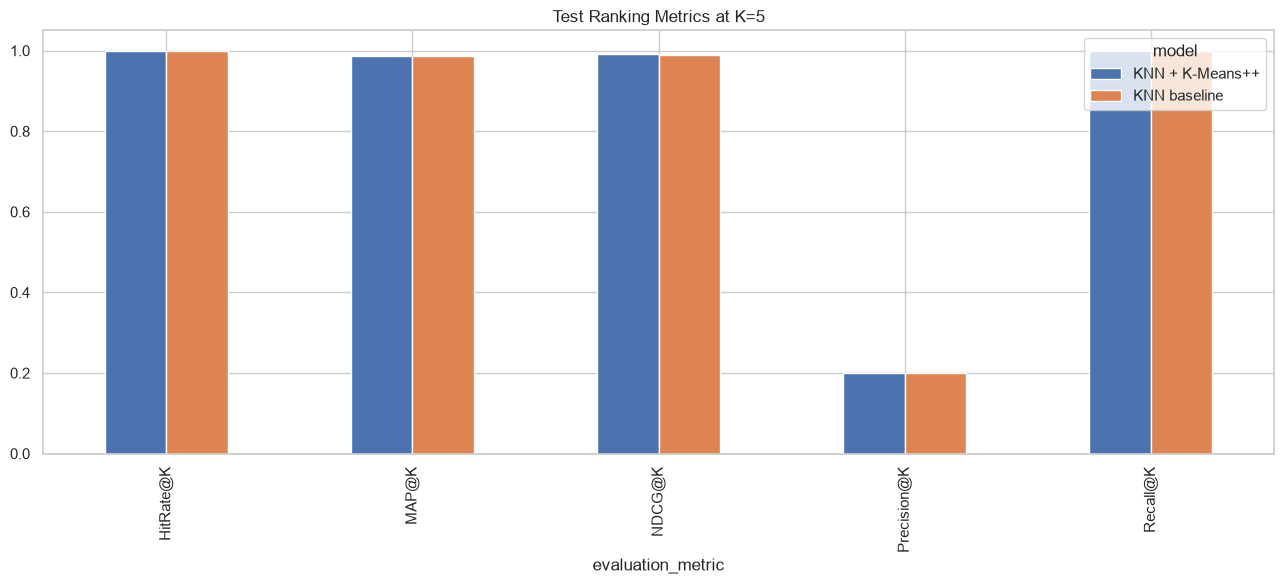

In [49]:
quality_long = test_results.melt(
    id_vars=["model", "metric"],
    value_vars=["Precision@K", "Recall@K", "MAP@K", "HitRate@K", "NDCG@K"],
    var_name="evaluation_metric",
    value_name="score",
)

plt.figure(figsize=(13, 6))
quality_pivot = quality_long.pivot_table(
    index="evaluation_metric", columns="model", values="score", aggfunc="mean"
)
quality_pivot.plot(kind="bar", ax=plt.gca())
plt.title(f"Test Ranking Metrics at K={TOP_K}")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

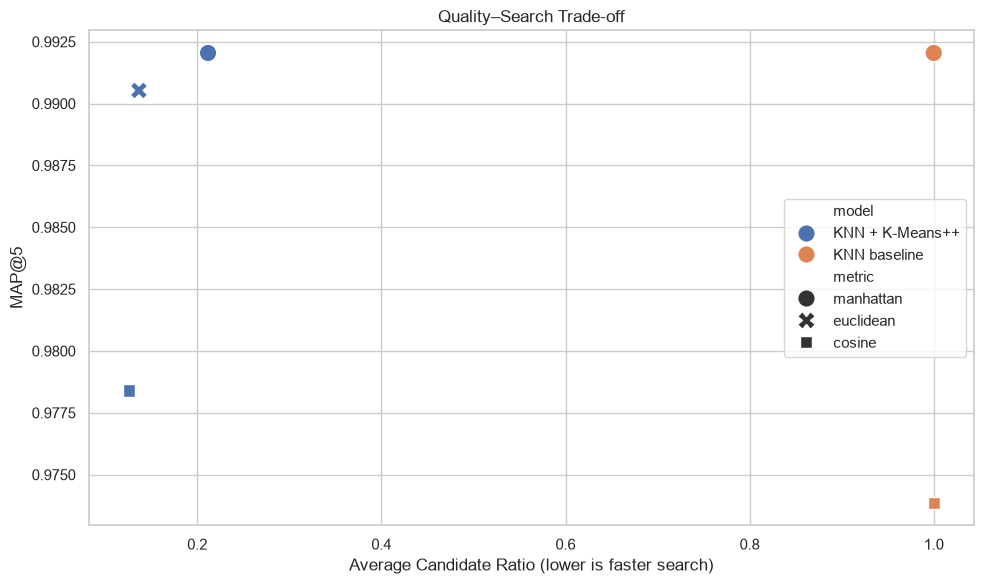

In [50]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=test_results,
    x="Candidate_ratio",
    y="MAP@K",
    hue="model",
    style="metric",
    s=160,
)
plt.title("Quality–Search Trade-off")
plt.xlabel("Average Candidate Ratio (lower is faster search)")
plt.ylabel(f"MAP@{TOP_K}")
plt.tight_layout()
plt.show()

In [51]:
comparison_rows = []
for metric in DISTANCE_METRICS:
    baseline_row = test_results[
        (test_results["model"] == "KNN baseline") &
        (test_results["metric"] == metric)
    ].iloc[0]
    hybrid_row = test_results[
        (test_results["model"] == "KNN + K-Means++") &
        (test_results["metric"] == metric)
    ].iloc[0]

    comparison_rows.append({
        "metric": metric,
        "baseline_MAP@K": baseline_row["MAP@K"],
        "hybrid_MAP@K": hybrid_row["MAP@K"],
        "MAP_delta": hybrid_row["MAP@K"] - baseline_row["MAP@K"],
        "baseline_NDCG@K": baseline_row["NDCG@K"],
        "hybrid_NDCG@K": hybrid_row["NDCG@K"],
        "NDCG_delta": hybrid_row["NDCG@K"] - baseline_row["NDCG@K"],
        "candidate_reduction_pct": (1 - hybrid_row["Candidate_ratio"]) * 100,
        "latency_change_pct": (
            (hybrid_row["Latency_ms_per_query"] / baseline_row["Latency_ms_per_query"] - 1) * 100
        ),
    })

model_comparison = pd.DataFrame(comparison_rows)
display(model_comparison.round(4))

,metric,baseline_MAP@K,hybrid_MAP@K,MAP_delta,baseline_NDCG@K,hybrid_NDCG@K,NDCG_delta,candidate_reduction_pct,latency_change_pct
0,euclidean,0.9920,0.9905,-0.0015,0.9941,0.9930,-0.0011,86.3365,1586.1015
1,manhattan,0.9920,0.9920,0.0000,0.9941,0.9941,0.0000,78.8272,2023.3315
2,cosine,0.9739,0.9784,0.0045,0.9807,0.9841,0.0034,87.4015,1629.7596


### How to interpret the comparison

- A positive `MAP_delta` or `NDCG_delta` means the optimized search improved ranking quality for that distance metric.
- A negative delta indicates a quality cost caused by approximate candidate search.
- `candidate_reduction_pct` directly shows how much of the training set the hybrid avoids scanning on average.
- Actual latency can vary with dataset size and implementation overhead. Candidate reduction becomes more valuable as the training set grows.

### Observed test findings

This cell converts the numerical results into concise, report-ready observations. The exact statements are generated from the current run instead of being hard-coded.

In [52]:
best_result = test_results.iloc[0]
print(
    f"Best ranking configuration: {best_result['model']} with {best_result['metric']} distance "
    f"(MAP@{TOP_K}={best_result['MAP@K']:.4f}, NDCG@{TOP_K}={best_result['NDCG@K']:.4f})."
)

for _, row in model_comparison.iterrows():
    speed_note = (
        "measured slower on this small dataset because Python-level cluster/candidate handling adds overhead"
        if row["latency_change_pct"] > 0
        else "measured faster in this run"
    )
    print(
        f"- {row['metric'].title()}: K-Means++ reduced the candidate set by "
        f"{row['candidate_reduction_pct']:.1f}%, changed MAP@{TOP_K} by "
        f"{row['MAP_delta']:+.4f}, and was {speed_note}."
    )

print(
    "Candidate reduction demonstrates the search-index effect. Runtime gains are expected to become "
    "more visible with larger datasets or a vectorized/compiled candidate-scoring implementation."
)

Best ranking configuration: KNN + K-Means++ with manhattan distance (MAP@5=0.9920, NDCG@5=0.9941).
- Euclidean: K-Means++ reduced the candidate set by 86.3%, changed MAP@5 by -0.0015, and was measured slower on this small dataset because Python-level cluster/candidate handling adds overhead.
- Manhattan: K-Means++ reduced the candidate set by 78.8%, changed MAP@5 by +0.0000, and was measured slower on this small dataset because Python-level cluster/candidate handling adds overhead.
- Cosine: K-Means++ reduced the candidate set by 87.4%, changed MAP@5 by +0.0045, and was measured slower on this small dataset because Python-level cluster/candidate handling adds overhead.
Candidate reduction demonstrates the search-index effect. Runtime gains are expected to become more visible with larger datasets or a vectorized/compiled candidate-scoring implementation.


## 16. Per-crop performance analysis

Aggregate metrics can hide crops that are difficult to recommend. The following table reports Top-$K$ hit rate and NDCG for every crop using the highest-MAP test configuration.

In [53]:
best_row = test_results.iloc[0]
best_model_name = f"{best_row['model']} | {best_row['metric']}"
best_detail = test_details[best_model_name]

per_crop = best_detail["per_query"].copy()
per_crop["true_crop"] = y_test.to_numpy()
per_crop_summary = (
    per_crop.groupby("true_crop")
    .agg(
        samples=("HitRate@K", "size"),
        HitRate_at_K=("HitRate@K", "mean"),
        MAP_at_K=("AP@K", "mean"),
        NDCG_at_K=("NDCG@K", "mean"),
        Mean_rank_when_hit=("rank", "mean"),
    )
    .sort_values(["HitRate_at_K", "NDCG_at_K"])
)

print(f"Best test configuration: {best_model_name}")
display(per_crop_summary.round(4))

Best test configuration: KNN + K-Means++ | manhattan


,samples,HitRate_at_K,MAP_at_K,NDCG_at_K,Mean_rank_when_hit
true_crop,,,,,
mothbeans,20,1.0,0.925,0.9446,1.15
maize,20,1.0,0.975,0.9815,1.05
orange,20,1.0,0.975,0.9815,1.05
pigeonpeas,20,1.0,0.975,0.9815,1.05
rice,20,1.0,0.975,0.9815,1.05
apple,20,1.0,1.000,1.0000,1.00
banana,20,1.0,1.000,1.0000,1.00
blackgram,20,1.0,1.000,1.0000,1.00
chickpea,20,1.0,1.000,1.0000,1.00


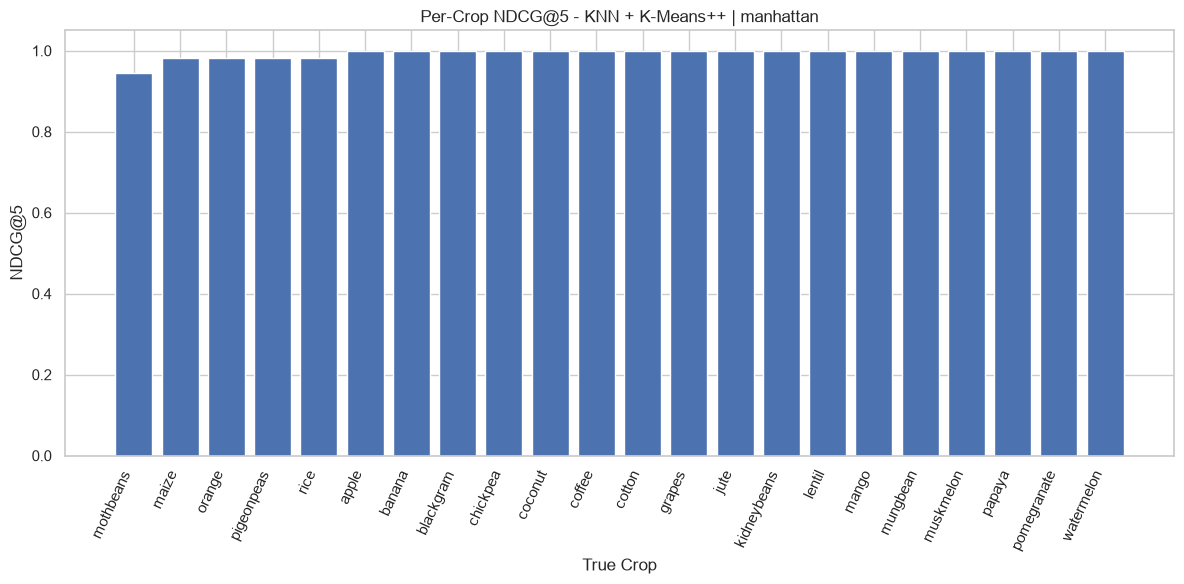

In [54]:
plt.figure(figsize=(12, 6))
per_crop_plot = per_crop_summary.reset_index()
plt.bar(per_crop_plot["true_crop"], per_crop_plot["NDCG_at_K"])
plt.title(f"Per-Crop NDCG@{TOP_K} - {best_model_name}")
plt.xlabel("True Crop")
plt.ylabel(f"NDCG@{TOP_K}")
plt.xticks(rotation=65, ha="right")
plt.tight_layout()
plt.show()

## 17. Inspect individual recommendations

The table below shows the true crop, ranked recommendations, rank of the true crop, and candidate-search size for test examples.

In [55]:
best_recs = best_detail["recommendations"]
best_diag = best_detail["diagnostics"]

examples = []
for i in range(min(15, len(X_test))):
    rec_list = list(best_recs[i])
    true_crop = y_test.iloc[i]
    true_rank = rec_list.index(true_crop) + 1 if true_crop in rec_list else None
    examples.append({
        "true_crop": true_crop,
        "recommendations": " > ".join(rec_list),
        "true_rank": true_rank,
        "candidates_examined": int(best_diag["candidate_count"][i]),
        "candidate_ratio": float(best_diag["candidate_ratio"][i]),
    })

display(pd.DataFrame(examples).round(4))

,true_crop,recommendations,true_rank,candidates_examined,candidate_ratio
0,orange,orange > pomegranate > mungbean > coconut > bl...,1,434,0.2466
1,banana,banana > cotton > watermelon > papaya > maize,1,409,0.2324
2,cotton,cotton > maize > watermelon > coffee > banana,1,409,0.2324
3,maize,maize > cotton > pigeonpeas > banana > kidneyb...,1,359,0.2040
4,orange,pomegranate > orange > coconut > maize > cotton,2,402,0.2284
5,chickpea,chickpea > kidneybeans > lentil > pigeonpeas >...,1,294,0.1670
6,rice,rice > papaya > jute > coconut > coffee,1,360,0.2045
7,blackgram,blackgram > lentil > mungbean > mothbeans > maize,1,473,0.2688
8,banana,banana > cotton > maize > watermelon > muskmelon,1,409,0.2324
9,orange,orange > pomegranate > coconut > lentil > moth...,1,348,0.1977


## 18. Reusable prediction function for new feature inputs

The function accepts raw, unscaled feature values and returns the Top-$K$ crops, distances, and normalized compatibility scores.

In [56]:
def recommend_from_raw_features(
    raw_features,
    model,
    imputer_obj=final_imputer,
    scaler_obj=final_scaler,
    feature_columns=FEATURE_COLUMNS,
    top_k=TOP_K,
):
    """
    raw_features can be:
      - a dictionary with feature names, or
      - a one-row pandas DataFrame.
    """
    if isinstance(raw_features, dict):
        query_df = pd.DataFrame([raw_features], columns=feature_columns)
    else:
        query_df = pd.DataFrame(raw_features).copy()
        query_df = query_df[feature_columns]

    query_scaled = scaler_obj.transform(imputer_obj.transform(query_df))
    recs, diagnostics = model.recommend(
        query_scaled, top_k=top_k, return_diagnostics=True
    )

    return pd.DataFrame({
        "rank": np.arange(1, len(recs[0]) + 1),
        "crop": recs[0],
        "distance_score": diagnostics["selected_distances"][0],
        "compatibility": diagnostics["compatibility"][0],
    })

In [57]:
# Demonstration using the first test sample (features only).
demo_features = X_test.iloc[0].to_dict()
print("Input features:")
display(pd.DataFrame([demo_features]))
print(f"Ground-truth crop: {y_test.iloc[0]}")
print(f"Model: {best_model_name}")

demo_recommendations = recommend_from_raw_features(
    demo_features,
    final_models[best_model_name],
    top_k=TOP_K,
)
display(demo_recommendations.round(4))

Input features:


,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
0,13.0,23.0,6.0,23.961476,90.26408,7.365338,102.69587


Ground-truth crop: orange
Model: KNN + K-Means++ | manhattan


,rank,crop,distance_score,compatibility
0,1,orange,0.9174,0.4365
1,2,pomegranate,1.7260,0.2320
2,3,mungbean,3.1353,0.1277
3,4,coconut,3.6401,0.1100
4,5,blackgram,4.2658,0.0939


## 19. Main conclusions

The final conclusions should be based on the generated `test_results` and `model_comparison` tables rather than assumed in advance.

1. **Scaling is necessary** because KNN and centroid search are distance-based and the raw feature scales differ substantially.
2. **Stratified train/validation/test splitting** preserves all 22 crop classes and prevents optimistic evaluation.
3. **PCA is useful for analysis**, but the final models retain all seven standardized features because dimensionality is already low.
4. **Distance metric selection matters:** Euclidean, Manhattan, and Cosine can rank crop suitability differently.
5. **KNN baseline** provides exact full-data search and serves as the quality reference.
6. **KNN + K-Means++** trades exact search for a smaller candidate set. Its success should be judged jointly by MAP/NDCG, candidate reduction, and latency.
7. With one ground-truth crop per row, **Recall@$K$ and Hit Rate@$K$ are equivalent**, while MAP@$K$ and NDCG@$K$ better distinguish rank positions.

### Recommended reporting format

Use the following evidence in the project report:

- dataset size, number of crop classes, and feature list;
- missing-value and scaling strategy;
- train/validation/test proportions;
- PCA cumulative explained variance;
- selected hyperparameters for each distance metric;
- final test metrics for both models;
- candidate reduction and latency;
- per-crop error analysis and example Top-$K$ outputs.

## 20. Optional export of experiment tables

Uncomment the following lines when CSV copies of the experiment results are needed for a report or presentation.

In [ ]:
baseline_validation.to_csv("baseline_validation_results.csv", index=False)
hybrid_validation.to_csv("hybrid_validation_results.csv", index=False)
test_results.to_csv("final_test_results.csv", index=False)
model_comparison.to_csv("model_comparison.csv", index=False)
per_crop_summary.to_csv("per_crop_performance.csv")